# Experimento 16: análisis por cláusulas y control del sobreajuste

Clasificación de sentimiento de reseñas, Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

En este experimento partimos de lo aprendido en los anteriores y probamos dos cosas: revisar qué tanto están sobreajustando los modelos y cambiar la forma de leer la reseña, pasando de oraciones a cláusulas. Solo usamos scikit-learn: TF-IDF de palabras y caracteres, regresión logística, LinearSVC, gradient boosting con árboles, validación cruzada, curvas de aprendizaje e importancia por permutación.

Contenido
1. Configuración
2. Revisión del sobreajuste y de cuánto se puede mejorar
3. Motivación del nuevo enfoque
4. Componentes del modelo
5. Comparación de combinadores con validación cruzada
6. Modelo del experimento 16: test, errores, robustez e interpretación
7. Envío y archivo del modelo
8. Conclusiones

## 1. Configuración

In [1]:
import re
import sys
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer, StandardScaler, PolynomialFeatures
from sklearn.svm import LinearSVC, SVC

SEED = 42
CLASES = ["negativo", "neutral", "positivo"]
N_JOBS = -1
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True})

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | pandas {pd.__version__}")

Python 3.14.2 | scikit-learn 1.9.0 | pandas 3.0.0


In [2]:
train = pd.read_csv("train.csv")
eval_df = pd.read_csv("eval.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("train:", train.shape, "| eval:", eval_df.shape, "| sample_submission:", sample_submission.shape)
train.head()

train: (12000, 3) | eval: (3000, 2) | sample_submission: (3000, 2)


,id,text,label
0,0,"Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo más de medio kilo. Lo tengo en el es...",neutral
1,1,"Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea dicha, el soporte técnico me resultó incumplidor para lo que necesitaba, tardaban ...",positivo
2,2,"Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficina casi a diario desde entonces. El diseño se sintió durable desde el primer día....",negativo
3,3,"Compré esto en línea y llegó en unos tres días a la casa. Venían varias unidades en el paquete, revisé todas una por una. El ensamblaje terminó siendo impreciso para lo que necesitaba, la verdad. ...",negativo
4,4,"Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. La verdad, el cargador me pareció terrible para mi gusto. Lo uso casi todos los ...",positivo


### 1.1 Funciones comunes

Son las mismas de los experimentos anteriores: normalización del texto, split 80/20 estratificado con 5 folds, reglas de conectores y frases evasivas, y el corrector de tipeo. La explicación de cada una está en `entrega_parte1.ipynb`.

In [3]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def normalizar_lote(textos):
    return [normalizar_texto(t) for t in textos]


casos = {
    "Pues aquÃ­ va mi reseÃ±a": "pues aqui va mi reseña",
    "El paquete llegò en cuatro dìas": "el paquete llego en cuatro dias",
    "Fue un errror, le pondría una estrellla": "fue un error, le pondria una estrella",
    "El año pasado  lo compré": "el año pasado lo compre",
}
for entrada, esperado in casos.items():
    assert normalizar_texto(entrada) == esperado
    print(f"{entrada:42} -> {normalizar_texto(entrada)}")

Pues aquÃ­ va mi reseÃ±a                   -> pues aqui va mi reseña
El paquete llegò en cuatro dìas            -> el paquete llego en cuatro dias
Fue un errror, le pondría una estrellla    -> fue un error, le pondria una estrella
El año pasado  lo compré                   -> el año pasado lo compre


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"X_train: {len(X_train):,} | X_test: {len(X_test):,}")
print("Proporción de clases en X_train:", y_train.value_counts(normalize=True).reindex(CLASES).round(3).to_dict())

X_train_norm = pd.Series(normalizar_lote(X_train), index=X_train.index)
X_test_norm = pd.Series(normalizar_lote(X_test), index=X_test.index)


def tfidf_palabras(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


def tfidf_caracteres(min_df=3):
    return TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=min_df, sublinear_tf=True)


PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")


def dividir_oraciones(texto):
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]

X_train: 9,600 | X_test: 2,400
Proporción de clases en X_train: {'negativo': 0.351, 'neutral': 0.298, 'positivo': 0.351}


In [5]:
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"
CONECTOR_INICIAL = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante|"
    r"para ser (honesto|honesta|sincero|sincera)|he de decir( que)?|la verdad( es que)?|por cierto|de paso|"
    r"por otro lado|ademas|eso si|sinceramente|para mi)\b[,:]?\s*"
)
GRUPOS = {
    "conclusivo": r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|no obstante|en fin|igual|ahora)\b",
    "secundario": r"^(y )?(de paso|por cierto|por otro lado|ademas)\b",
    "esosi": r"^(y )?(eso si|la verdad)\b",
}
NOMBRES_GRUPO = ["conclusivo", "secundario", "esosi", "ninguno"]


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def quitar_conector(oracion):
    return re.sub(CONECTOR_INICIAL, "", oracion)


def grupo_conector(oracion):
    for grupo, patron in GRUPOS.items():
        if re.match(patron, oracion):
            return grupo
    return "ninguno"

In [6]:
LETRAS = "abcdefghijklmnopqrstuvwxyzñ"
PATRON_PALABRA = re.compile(r"[a-zñ]+")


def ediciones_distancia_1(palabra):
    cortes = [(palabra[:i], palabra[i:]) for i in range(len(palabra) + 1)]
    borrados = [a + b[1:] for a, b in cortes if b]
    transposiciones = [a + b[1] + b[0] + b[2:] for a, b in cortes if len(b) > 1]
    sustituciones = [a + c + b[1:] for a, b in cortes if b for c in LETRAS]
    inserciones = [a + c + b for a, b in cortes for c in LETRAS]
    return set(borrados + transposiciones + sustituciones + inserciones)


class CorrectorTipeo(BaseEstimator, TransformerMixin):

    def __init__(self, max_rara=2, min_frecuente=15, min_largo=4):
        self.max_rara = max_rara
        self.min_frecuente = min_frecuente
        self.min_largo = min_largo

    def fit(self, X, y=None):
        self.frecuencias_ = Counter(p for texto in X for p in PATRON_PALABRA.findall(texto))
        self.frecuentes_ = {p: f for p, f in self.frecuencias_.items() if f >= self.min_frecuente}
        self.correcciones_ = {}
        for palabra, f in self.frecuencias_.items():
            if f <= self.max_rara and len(palabra) >= self.min_largo:
                candidatas = [c for c in ediciones_distancia_1(palabra) if c in self.frecuentes_]
                if candidatas:
                    self.correcciones_[palabra] = max(candidatas, key=self.frecuentes_.get)
        return self

    def _corregir(self, palabra):
        if palabra in self.correcciones_:
            return self.correcciones_[palabra]
        if palabra not in self.frecuencias_ and len(palabra) >= self.min_largo:
            candidatas = [c for c in ediciones_distancia_1(palabra) if c in self.frecuentes_]
            if candidatas:
                return max(candidatas, key=self.frecuentes_.get)
        return palabra

    def transform(self, X):
        return [PATRON_PALABRA.sub(lambda m: self._corregir(m.group()), texto) for texto in X]

## 2. Revisión del sobreajuste

Comparar la accuracy de entrenamiento con la de validación no es suficiente si no sabemos cuál es la accuracy máxima que se puede alcanzar. Si una parte de las etiquetas es aleatoria, un modelo que acierta casi todo en entrenamiento está memorizando esas etiquetas.

### 2.1 ¿Se puede predecir la etiqueta de las reseñas que terminan en frase evasiva?

En los experimentos 4 y 5 vimos que cerca del 16 % de las reseñas negativas y positivas terminan con una frase evasiva ("cada quien que juzgue", "sigo con dudas"). Para revisarlo entrenamos un modelo usando solo esas reseñas y distintas partes del texto. Si ninguna parte pasa del 50 %, la etiqueta no depende del texto.

In [7]:
termina_evasiva_tr = X_train_norm.map(lambda t: es_evasiva(dividir_oraciones(t)[-1]))
grupo_ruidoso = (y_train != "neutral") & termina_evasiva_tr
print(f"Reseñas negativo/positivo con final evasivo en X_train: {grupo_ruidoso.sum():,} "
      f"({grupo_ruidoso.sum() / (y_train != 'neutral').sum():.1%} de las negativo/positivo)")

VISTAS = {
    "texto completo": lambda t: t,
    "texto sin la última oración": lambda t: " ".join(dividir_oraciones(t)[:-1]),
    "penúltima oración": lambda t: (dividir_oraciones(t)[-2:-1] or [""])[0],
    "primera oración": lambda t: dividir_oraciones(t)[0],
}
senal = {}
for nombre, vista in VISTAS.items():
    modelo = Pipeline([("tfidf", tfidf_palabras()), ("clf", LogisticRegression(C=0.1, max_iter=3000))])
    senal[nombre] = cross_val_score(modelo, X_train_norm[grupo_ruidoso].map(vista), y_train[grupo_ruidoso],
                                    cv=StratifiedKFold(5, shuffle=True, random_state=SEED)).mean()
pd.Series(senal, name="accuracy CV dentro del grupo").round(3).to_frame()

Reseñas negativo/positivo con final evasivo en X_train: 1,078 (16.0% de las negativo/positivo)


,accuracy CV dentro del grupo
texto completo,0.518
texto sin la última oración,0.526
penúltima oración,0.502
primera oración,0.498


Todas las variantes dan entre 0,50 y 0,53, que es lo mismo que adivinar (la clase mayoritaria del grupo es 51 %). En este grupo la etiqueta parece asignada al azar. Si sumamos el grupo de conectores secundarios contradictorios del experimento 5, alrededor del 12,6 % de las reseñas tienen una etiqueta que no se puede predecir, así que el techo de accuracy para cualquier modelo está cerca de 0,937.

### 2.2 Diferencia entre entrenamiento y validación en modelos anteriores

Los valores salen de cada notebook. La columna "exceso sobre el techo" es la accuracy de entrenamiento menos 0,937: lo que un modelo acierta por encima de ese valor solo lo puede lograr memorizando etiquetas aleatorias.

In [8]:
TECHO = 0.937
brechas = pd.DataFrame([
    ("Exp. 1: línea base (TF-IDF + LR)", 0.9973, 0.7364),
    ("Exp. 4: detector de opinión + LinearSVC", 0.9770, 0.9009),
    ("Exp. 9: dos niveles, nivel 1 (LinearSVC)", 0.9770, None),
    ("Exp. 9: dos niveles, modelo completo", 0.9358, 0.9065),
    ("Exp. 12: un nivel, chi² y sin ruidosas", 0.9190, 0.9033),
], columns=["modelo", "acc_train", "acc_cv"]).set_index("modelo")
brechas["brecha (puntos)"] = ((brechas["acc_train"] - brechas["acc_cv"]) * 100).round(1)
brechas["exceso sobre el techo (puntos)"] = ((brechas["acc_train"] - TECHO) * 100).round(1).clip(lower=0)
brechas

,acc_train,acc_cv,brecha (puntos),exceso sobre el techo (puntos)
modelo,,,,
Exp. 1: línea base (TF-IDF + LR),0.9973,0.7364,26.1,6.0
Exp. 4: detector de opinión + LinearSVC,0.9770,0.9009,7.6,4.0
"Exp. 9: dos niveles, nivel 1 (LinearSVC)",0.9770,NaN,NaN,4.0
"Exp. 9: dos niveles, modelo completo",0.9358,0.9065,2.9,0.0
"Exp. 12: un nivel, chi² y sin ruidosas",0.9190,0.9033,1.6,0.0


Lo que se observa:
- La línea base sobreajusta mucho, con 26 puntos de diferencia. Memoriza los n-gramas de cada reseña.
- Los modelos de texto de un solo nivel (el LinearSVC del experimento 4 y el nivel 1 del experimento 9) llegan a 97,7 % en entrenamiento, unos 4 puntos por encima del techo. Con 42.000 n-gramas para 9.600 reseñas les resulta fácil memorizar las etiquetas aleatorias.
- El modelo del experimento 9 tiene 3 puntos de diferencia, pero su accuracy de entrenamiento (0,936) está justo en el techo, así que el combinador no está memorizando ruido. Esto se debe al cross-fitting: el nivel 2 aprende con puntajes de reseñas que el nivel 1 no vio.
- En resumen, el sobreajuste del modelo entregado está controlado y parte de la diferencia no se puede evitar, porque en validación las etiquetas aleatorias solo se aciertan la mitad de las veces. No es lo que explica la mayoría de los errores que quedan.

### 2.3 Curva de aprendizaje

Usamos un modelo rápido de un nivel (texto completo y última parte con opinión, TF-IDF y LinearSVC). Si la curva de validación sigue subiendo al final, tener más datos ayudaría. Si se aplana, el límite está en la representación o en el ruido.

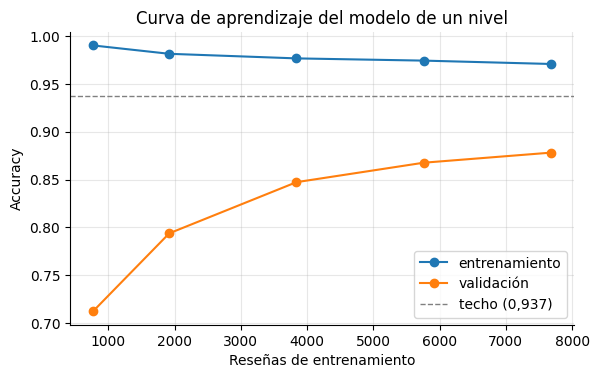

,n,train,validación
0,768,0.9901,0.7123
1,1920,0.9814,0.7939
2,3840,0.9766,0.8473
3,5760,0.9742,0.8676
4,7680,0.9707,0.8781


In [9]:
def ultima_parte_sin_evasiva(textos):
    return pd.DataFrame({"texto": list(textos), "ultima": [sin_evasivas(t)[-1] for t in textos]})


modelo_rapido = Pipeline([
    ("partes", FunctionTransformer(ultima_parte_sin_evasiva)),
    ("tfidf", ColumnTransformer([("t", tfidf_palabras(), "texto"), ("u", tfidf_palabras(), "ultima")])),
    ("clf", LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
])
tamanos, acc_tr, acc_va = learning_curve(modelo_rapido, X_train_norm, y_train, cv=skf, n_jobs=N_JOBS,
                                         train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0])
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(tamanos, acc_tr.mean(axis=1), marker="o", label="entrenamiento")
ax.plot(tamanos, acc_va.mean(axis=1), marker="o", label="validación")
ax.axhline(TECHO, ls="--", color="gray", lw=1, label="techo (0,937)")
ax.set_xlabel("Reseñas de entrenamiento")
ax.set_ylabel("Accuracy")
ax.set_title("Curva de aprendizaje del modelo de un nivel")
ax.legend()
plt.show()
pd.DataFrame({"n": tamanos, "train": acc_tr.mean(axis=1), "validación": acc_va.mean(axis=1)}).round(4)

La curva de entrenamiento queda por encima del techo en todos los tamaños, lo que indica que memoriza ruido. La de validación crece cada vez menos, así que duplicar los datos mejoraría poco. Para mejorar hay que representar mejor la estructura de la reseña y evitar aprender el ruido.

## 3. Motivación del nuevo enfoque

### 3.1 Resumen del enfoque del experimento 9
1. Normaliza el texto y corrige tipeos.
2. Divide la reseña en oraciones y un detector de opinión busca la última oración con opinión.
3. Un LinearSVC lee tres partes con TF-IDF (texto completo, última opinión y texto después del último conector) y da un puntaje por clase.
4. Un modelo de polaridad lee las últimas opiniones y se calculan variables de estructura (conectores y frases evasivas).
5. Un SVM RBF combina todo usando stacking con cross-fitting.

### 3.2 Análisis de errores
Con predicciones de validación cruzada sobre `X_train` hay unos 900 errores. Cerca de 520 son del grupo con etiqueta aleatoria y no se pueden corregir. En los 380 restantes encontramos estos patrones:

| Patrón | Ejemplo | Posible solución |
|---|---|---|
| Dos opiniones en la misma oración | "la autonomía se mantuvo redonda, pero la resistencia al agua resultó defectuosa" | dividir en cláusulas y no solo en oraciones |
| Palabras de polaridad poco frecuentes o mal escritas | "el procesador me resultó sólido", "funciona bastante mal, la probé apeas" | n-gramas de caracteres en el modelo de polaridad |
| Cierres evasivos que no están en la lista | "ahí lo dejamos", "es lo que hay por ahora" | no se pueden acertar, pero se puede evitar aprenderlos |
| Combinador que memoriza | árboles sin regularizar con 97 % en entrenamiento | regularizar el combinador y revisar la diferencia train−CV |

### 3.3 Qué cambia en el experimento 16

| | Experimento 9 | Experimento 16 |
|---|---|---|
| Unidad de análisis | oración | cláusula (la oración se corta antes de cada conector) |
| Detector de opinión | por oración | por cláusula |
| Modelo de polaridad | TF-IDF de palabras | TF-IDF de palabras y de caracteres (2 a 5) |
| Combinador | SVM RBF | gradient boosting con árboles de 4 hojas y regularización |
| Interpretación | no se hizo | importancia por permutación |

Hipótesis: leer la reseña por cláusulas, con una polaridad que tolere tipeos, debería mejorar la lectura de la última opinión, y un combinador regularizado debería mantener la accuracy sin memorizar ruido.

## 4. Componentes del modelo

### 4.1 Segmentación en cláusulas

Cada oración se corta justo antes de un conector (pero, sin embargo, aunque, por otro lado, eso sí, etc.). Para esto usamos un lookahead `(?=...)` en la expresión regular, que corta en esa posición sin quitar el conector. Así la cláusula conserva la palabra inicial, que necesitamos para saber de qué tipo es.

In [10]:
CONECTOR_CLAUSULA = (
    r"(?:,\s*|\s+)(?=(?:pero|sin embargo|aunque|aun asi|eso si|por otro lado|por cierto|ademas|de paso|"
    r"no obstante|en cambio|al final|con todo|igual)\b)"
)


def dividir_clausulas(texto):
    clausulas = []
    for oracion in dividir_oraciones(texto):
        clausulas += [c.strip(" ,") for c in re.split(CONECTOR_CLAUSULA, oracion) if c.strip(" ,")]
    return clausulas or [texto]


def clausulas_sin_evasivas(texto):
    clausulas = dividir_clausulas(texto)
    return [c for c in clausulas if not es_evasiva(c)] or clausulas


ejemplo = normalizar_texto("La uso casi todos los días, y por cierto la autonomía se mantuvo redonda, pero la "
                           "resistencia al agua me resultó defectuosa con el tiempo. Lo dejo a tu criterio.")
print("Oraciones :", dividir_oraciones(ejemplo))
print("Cláusulas :", dividir_clausulas(ejemplo))
print("Sin evasivas:", clausulas_sin_evasivas(ejemplo))

Oraciones : ['la uso casi todos los dias, y por cierto la autonomia se mantuvo redonda, pero la resistencia al agua me resulto defectuosa con el tiempo.', 'lo dejo a tu criterio.']
Cláusulas : ['la uso casi todos los dias, y', 'por cierto la autonomia se mantuvo redonda', 'pero la resistencia al agua me resulto defectuosa con el tiempo.', 'lo dejo a tu criterio.']
Sin evasivas: ['la uso casi todos los dias, y', 'por cierto la autonomia se mantuvo redonda', 'pero la resistencia al agua me resulto defectuosa con el tiempo.']


Antes de construir el modelo completo hacemos una prueba rápida con un solo nivel y sin detector: texto completo más la última cláusula no evasiva, contra texto completo más la última oración no evasiva. Mismo clasificador y mismos folds.

In [11]:
def modelo_ultima(funcion_ultima):
    def partes(textos):
        return pd.DataFrame({"texto": list(textos), "ultima": [funcion_ultima(t) for t in textos]})
    return Pipeline([
        ("partes", FunctionTransformer(partes)),
        ("tfidf", ColumnTransformer([("t", tfidf_palabras(), "texto"), ("u", tfidf_palabras(), "ultima")])),
        ("clf", LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ])


def ultima_oracion_ok(t):
    return sin_evasivas(t)[-1]


def ultima_clausula_ok(t):
    return clausulas_sin_evasivas(t)[-1]


ablacion = pd.DataFrame({
    nombre: cross_val_score(modelo_ultima(f), X_train_norm, y_train, cv=skf, n_jobs=N_JOBS)
    for nombre, f in [("última oración", ultima_oracion_ok), ("última cláusula", ultima_clausula_ok)]
}, index=[f"fold {k}" for k in range(1, 6)]).T
ablacion["media"] = ablacion.mean(axis=1)
ablacion.round(4)

,fold 1,fold 2,fold 3,fold 4,fold 5,media
última oración,0.8839,0.8724,0.8859,0.8885,0.8599,0.8781
última cláusula,0.8865,0.8865,0.8891,0.8896,0.8698,0.8843


### 4.2 Nivel 1 por cláusulas

La clase `NivelClausulas` reúne todo lo que se aprende del texto. En `fit`, usando solo los datos de entrenamiento:
1. Ajusta el corrector de tipeo (no usa etiquetas).
2. Entrena un detector de opinión por cláusula (TF-IDF y regresión logística). Las cláusulas de reseñas neutrales son los ejemplos sin opinión, y las cláusulas de reseñas negativas o positivas que empiezan con un conector y no son evasivas son los ejemplos con opinión.
3. Entrena el modelo de polaridad (TF-IDF de palabras y caracteres con regresión logística) con la última cláusula con opinión de las reseñas negativas y positivas que no terminan en evasiva. Las que terminan en evasiva se dejan por fuera porque su etiqueta es aleatoria.
4. Entrena un LinearSVC sobre tres partes con TF-IDF: texto completo, última cláusula con opinión y texto después del último conector.

El método `features` devuelve 15 variables por reseña, con las mismas ideas del experimento 9 pero por cláusulas: los 3 puntajes del LinearSVC, la polaridad de las 3 últimas opiniones, el número de opiniones, si termina en evasiva, si hay opiniones opuestas y el tipo de conector de la última y la penúltima opinión.

In [12]:
GRUPOS = {
    "conclusivo": r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|no obstante|en fin|igual|ahora|aunque|en cambio)\b",
    "secundario": r"^(y )?(de paso|por cierto|por otro lado|ademas)\b",
    "esosi": r"^(y )?(eso si|la verdad)\b",
}
NOMBRES_GRUPO = ["conclusivo", "secundario", "esosi", "ninguno"]
NOMBRES_FEATURES = (["svc_negativo", "svc_neutral", "svc_positivo", "pol_antepenultima", "pol_penultima",
                     "pol_ultima", "n_opiniones", "termina_evasiva", "opiniones_opuestas"]
                    + [f"ultima_{g}" for g in NOMBRES_GRUPO] + [f"penultima_{g}" for g in NOMBRES_GRUPO])


def grupo_conector(clausula):
    for grupo, patron in GRUPOS.items():
        if re.match(patron, clausula):
            return grupo
    return "ninguno"


class NivelClausulas(BaseEstimator):

    def __init__(self, umbral=0.5, C_svc=0.2, C_polaridad=3):
        self.umbral = umbral
        self.C_svc = C_svc
        self.C_polaridad = C_polaridad

    def fit(self, X, y):
        y = np.asarray(y)
        self.corrector_ = CorrectorTipeo().fit(X)
        X = self.corrector_.transform(X)

        con_opinion, sin_opinion = [], []
        for texto, etiqueta in zip(X, y):
            clausulas = dividir_clausulas(texto)
            if etiqueta == "neutral":
                sin_opinion += clausulas
                continue
            con_opinion += [c for c in clausulas
                            if (re.match(CONCLUSIVOS, c) or re.match(CONCESIVOS, c)) and not es_evasiva(c)]
        self.detector_ = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
        ]).fit([quitar_conector(c) for c in con_opinion + sin_opinion],
               [1] * len(con_opinion) + [0] * len(sin_opinion))

        limpias = (y != "neutral") & np.array([not es_evasiva(dividir_oraciones(t)[-1]) for t in X])
        ultimas = [quitar_conector(self.opiniones(t)[-1]) for t, ok in zip(X, limpias) if ok]
        self.polaridad_ = Pipeline([
            ("tfidf", FeatureUnion([("palabras", tfidf_palabras()), ("caracteres", tfidf_caracteres())])),
            ("clf", LogisticRegression(C=self.C_polaridad, max_iter=3000, random_state=SEED)),
        ]).fit(ultimas, y[limpias])

        partes = self.partes(X)
        self.tfidf_ = ColumnTransformer([(c, tfidf_palabras(), c) for c in partes.columns]).fit(partes)
        self.svc_ = LinearSVC(C=self.C_svc, max_iter=5000, random_state=SEED).fit(self.tfidf_.transform(partes), y)
        return self

    def opiniones(self, texto):
        candidatas = clausulas_sin_evasivas(texto)
        prob = self.detector_.predict_proba([quitar_conector(c) for c in candidatas])[:, 1]
        con_opinion = [c for c, p in zip(candidatas, prob) if p >= self.umbral]
        return con_opinion or [candidatas[-1]]

    def partes(self, X):
        return pd.DataFrame([{"texto": t, "ultima_op": self.opiniones(t)[-1],
                              "tras_conector": tras_ultimo_conector(" ".join(sin_evasivas(t)))} for t in X])

    def features(self, X):
        X = self.corrector_.transform(list(X))
        puntajes = self.svc_.decision_function(self.tfidf_.transform(self.partes(X)))
        estructura = []
        for texto in X:
            ops = self.opiniones(texto)
            pols = list(self.polaridad_.decision_function([quitar_conector(o) for o in ops[-3:]]))
            pols = [0.0] * (3 - len(pols)) + pols
            g_ult = grupo_conector(ops[-1])
            g_pen = grupo_conector(ops[-2]) if len(ops) > 1 else "ninguno"
            fila = pols + [len(ops), float(es_evasiva(dividir_oraciones(texto)[-1])), float(pols[-1] * pols[-2] < 0)]
            fila += [float(g_ult == g) for g in NOMBRES_GRUPO] + [float(g_pen == g) for g in NOMBRES_GRUPO]
            estructura.append(fila)
        return np.hstack([puntajes, np.array(estructura)])


nivel_demo = NivelClausulas().fit(list(X_train_norm), y_train)
ejemplo_2 = normalizar_texto("Lo pedí un martes y llegó el jueves. La calidad se queda muy corta, la verdad. "
                             "La correa está bien, le pondría cinco estrellas.")
print("Opiniones detectadas:", nivel_demo.opiniones(ejemplo_2))
pd.DataFrame(nivel_demo.features([ejemplo_2]), columns=NOMBRES_FEATURES).round(2).T

Opiniones detectadas: ['la calidad se queda muy corta, la verdad.', 'la correa esta bien, le pondria cinco estrellas.']


,0
svc_negativo,-0.26
svc_neutral,-1.36
svc_positivo,0.27
pol_antepenultima,0.00
pol_penultima,-1.77
pol_ultima,0.90
n_opiniones,2.00
termina_evasiva,0.00
opiniones_opuestas,1.00
ultima_conclusivo,0.00


### 4.3 Cross-fitting y modelo de dos niveles

Igual que en los experimentos 6 a 9, las variables con las que aprende el combinador se calculan con 5 particiones internas, de modo que cada reseña se puntúa con un nivel 1 que no la vio. Después el nivel 1 se vuelve a entrenar con todos los datos.

In [13]:
def features_cross_fitting(X, y, k=5, nivel1=None):
    X, y = list(X), np.asarray(y)
    F = None
    for idx_tr, idx_va in StratifiedKFold(k, shuffle=True, random_state=SEED).split(X, y):
        nivel = clone(nivel1 if nivel1 is not None else NivelClausulas())
        nivel.fit([X[i] for i in idx_tr], y[idx_tr])
        f_va = nivel.features([X[i] for i in idx_va])
        if F is None:
            F = np.zeros((len(X), f_va.shape[1]))
        F[idx_va] = f_va
    return F


class ModeloClausulas(BaseEstimator, ClassifierMixin):

    def __init__(self, combinador=None, nivel1=None):
        self.combinador = combinador
        self.nivel1 = nivel1

    def fit(self, X, y):
        X, y = list(X), np.asarray(y)
        F = features_cross_fitting(X, y, nivel1=self.nivel1)
        self.nivel1_ = clone(self.nivel1 if self.nivel1 is not None else NivelClausulas()).fit(X, y)
        self.combinador_ = clone(self.combinador).fit(F, y)
        self.classes_ = self.combinador_.classes_
        return self

    def predict(self, X):
        return self.combinador_.predict(self.nivel1_.features(list(X)))

## 5. Comparación de combinadores

Las variables del nivel 2 se calculan una sola vez por fold (unos 5 minutos) y se guardan, para comparar todos los combinadores con las mismas variables y los mismos folds. Para cada uno mostramos la accuracy de entrenamiento, la de validación y la diferencia entre las dos.

In [14]:
def fold_externo(idx_tr, idx_va):
    X_tr, y_tr = [X_train_norm.iloc[i] for i in idx_tr], y_train.iloc[idx_tr].to_numpy()
    F_tr = features_cross_fitting(X_tr, y_tr)
    F_va = NivelClausulas().fit(X_tr, y_tr).features([X_train_norm.iloc[i] for i in idx_va])
    return F_tr, F_va, y_tr, y_train.iloc[idx_va].to_numpy()


inicio = time.time()
CACHE = joblib.Parallel(n_jobs=N_JOBS)(joblib.delayed(fold_externo)(tr, va) for tr, va in skf.split(X_train, y_train))
print(f"Features de nivel 2 de los 5 folds en {(time.time() - inicio) / 60:.1f} min")

Features de nivel 2 de los 5 folds en 4.2 min


In [15]:
def hgb(max_leaf_nodes=15, min_samples_leaf=20, learning_rate=0.05, max_iter=200, l2=0.0):
    return HistGradientBoostingClassifier(max_leaf_nodes=max_leaf_nodes, min_samples_leaf=min_samples_leaf,
                                          learning_rate=learning_rate, max_iter=max_iter,
                                          l2_regularization=l2, random_state=SEED)


COMBINADORES = {
    "Regresión logística": lambda: Pipeline([("escala", StandardScaler()),
                                             ("clf", LogisticRegression(C=1, max_iter=5000))]),
    "LR + interacciones grado 2": lambda: Pipeline([
        ("escala", StandardScaler()), ("inter", PolynomialFeatures(2, include_bias=False)),
        ("escala2", StandardScaler()), ("clf", LogisticRegression(C=0.03, max_iter=5000))]),
    "SVM RBF (como exp. 9)": lambda: Pipeline([("escala", StandardScaler()), ("clf", SVC(C=1, random_state=SEED))]),
    "HGB por defecto (15 hojas)": lambda: hgb(),
    "HGB regularizado (7 hojas, ≥50 por hoja)": lambda: hgb(7, 50, 0.03, 300, 1.0),
    "HGB muy simple (4 hojas, ≥100 por hoja)": lambda: hgb(4, 100, 0.05, 300, 1.0),
}

ACC_FOLDS_E9 = np.array([0.9115, 0.9016, 0.9161, 0.9109, 0.8911])

filas, folds = [], {"[ref.] Exp. 9 (oraciones, SVM RBF)": ACC_FOLDS_E9}
for nombre, fabrica in COMBINADORES.items():
    acc_va, acc_tr = [], []
    for F_tr, F_va, y_tr, y_va in CACHE:
        modelo = fabrica().fit(F_tr, y_tr)
        acc_tr.append(accuracy_score(y_tr, modelo.predict(F_tr)))
        acc_va.append(accuracy_score(y_va, modelo.predict(F_va)))
    folds[nombre] = np.array(acc_va)
    filas.append({"combinador": nombre, "acc_train": np.mean(acc_tr), "acc_cv": np.mean(acc_va),
                  "std_cv": np.std(acc_va), "brecha (puntos)": (np.mean(acc_tr) - np.mean(acc_va)) * 100,
                  "folds que gana al exp. 9": int((np.array(acc_va) > ACC_FOLDS_E9).sum())})

tabla_comb = pd.DataFrame(filas).set_index("combinador").sort_values("acc_cv", ascending=False)
tabla_comb.round(4)

,acc_train,acc_cv,std_cv,brecha (puntos),folds que gana al exp. 9
combinador,,,,,
"HGB regularizado (7 hojas, ≥50 por hoja)",0.9326,0.9083,0.0059,2.4245,3
"HGB muy simple (4 hojas, ≥100 por hoja)",0.9245,0.9070,0.0085,1.7474,3
HGB por defecto (15 hojas),0.9726,0.9057,0.0063,6.6901,2
Regresión logística,0.9047,0.9056,0.0063,-0.0964,2
LR + interacciones grado 2,0.9116,0.9049,0.0074,0.6719,3
SVM RBF (como exp. 9),0.9174,0.9018,0.0059,1.5625,1


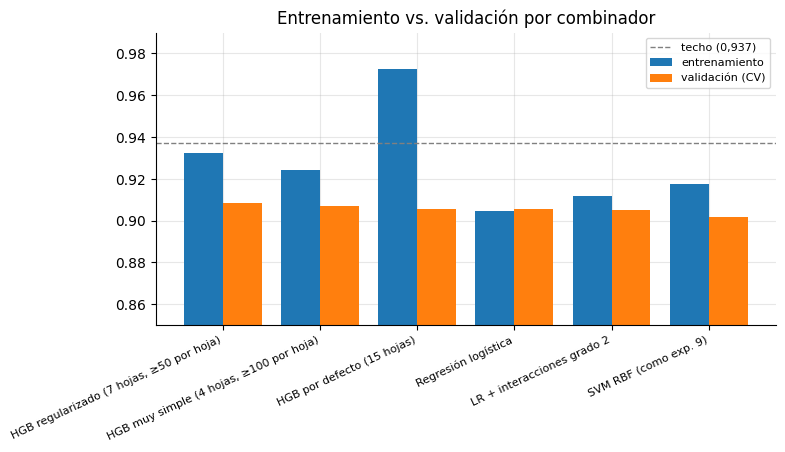

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(tabla_comb))
ax.bar(x - 0.2, tabla_comb["acc_train"], width=0.4, label="entrenamiento")
ax.bar(x + 0.2, tabla_comb["acc_cv"], width=0.4, label="validación (CV)")
ax.axhline(TECHO, ls="--", color="gray", lw=1, label="techo (0,937)")
ax.set_xticks(x, tabla_comb.index, rotation=25, ha="right", fontsize=8)
ax.set_ylim(0.85, 0.99)
ax.set_title("Entrenamiento vs. validación por combinador")
ax.legend(fontsize=8)
plt.show()

Resultados:
- Los combinadores lineales no sobreajustan (entrenamiento y validación son casi iguales), pero quedan un poco por debajo porque no capturan interacciones entre variables.
- El gradient boosting con los valores por defecto memoriza: 97 % en entrenamiento, por encima del techo, con unos 6 puntos de diferencia. Al limitar el tamaño de los árboles (7 o 4 hojas, con mínimo 50 o 100 reseñas por hoja) y agregar regularización L2, el entrenamiento baja a 0,92–0,93, por debajo del techo, y la validación se mantiene o sube.
- Los dos gradient boosting regularizados tienen las mejores accuracies de CV que hemos obtenido (entre 0,907 y 0,909), y la diferencia entre ellos es menor que la variación entre folds. Como están empatados elegimos el más simple, el de árboles de 4 hojas, que además tiene la menor diferencia entre entrenamiento y validación (1,7 puntos).
- Frente al experimento 9 (0,906) la mejora es de 0,1 a 0,3 puntos, menor que la variación entre folds. Lo tomamos como un empate, con la ventaja de que este modelo memoriza menos y se puede interpretar.

Los hiperparámetros se eligieron con esta misma tabla de validación cruzada, probando solo 3 configuraciones. El test no se usó para decidir.

### 5.1 Entrenar el combinador sin las reseñas de etiqueta aleatoria

Aplicamos la idea del experimento 12 al nivel 2: quitar del entrenamiento del combinador las reseñas negativas y positivas que terminan en evasiva (cuando `termina_evasiva` vale 1).

In [17]:
IDX_EVASIVA = NOMBRES_FEATURES.index("termina_evasiva")
filas = []
for nombre in ["Regresión logística", "HGB regularizado (7 hojas, ≥50 por hoja)"]:
    for filtrar in (False, True):
        acc_va, acc_tr = [], []
        for F_tr, F_va, y_tr, y_va in CACHE:
            usar = ~((F_tr[:, IDX_EVASIVA] == 1) & (y_tr != "neutral")) if filtrar else np.ones(len(y_tr), bool)
            modelo = COMBINADORES[nombre]().fit(F_tr[usar], y_tr[usar])
            acc_tr.append(accuracy_score(y_tr, modelo.predict(F_tr)))
            acc_va.append(accuracy_score(y_va, modelo.predict(F_va)))
        filas.append({"combinador": nombre, "sin reseñas ruidosas": filtrar,
                      "acc_train": np.mean(acc_tr), "acc_cv": np.mean(acc_va)})
pd.DataFrame(filas).round(4)

,combinador,sin reseñas ruidosas,acc_train,acc_cv
0,Regresión logística,False,0.9047,0.9056
1,Regresión logística,True,0.9045,0.9048
2,"HGB regularizado (7 hojas, ≥50 por hoja)",False,0.9326,0.9083
3,"HGB regularizado (7 hojas, ≥50 por hoja)",True,0.9186,0.9075


Con un combinador regularizado, quitar esas reseñas no mejora y hasta empeora un poco. Esas reseñas le enseñan al combinador que cuando hay un final evasivo no debe confiar tanto en el nivel 1, y la regularización ya evita que memorice su etiqueta. Por eso las dejamos todas.

## 6. Modelo del experimento 16

### 6.1 Test hold-out

CV experimento 16: 0.9070 ± 0.0085 | experimento 9: 0.9062 ± 0.0089
Entrenamiento en 3.3 min

Test -> accuracy: 0.9104 | F1 macro: 0.9147  (exp. 9: 0,9029)

              precision    recall  f1-score   support

    negativo      0.870     0.881     0.876       843
     neutral      0.996     0.997     0.997       715
    positivo      0.878     0.866     0.872       842

    accuracy                          0.910      2400
   macro avg      0.915     0.915     0.915      2400
weighted avg      0.910     0.910     0.910      2400



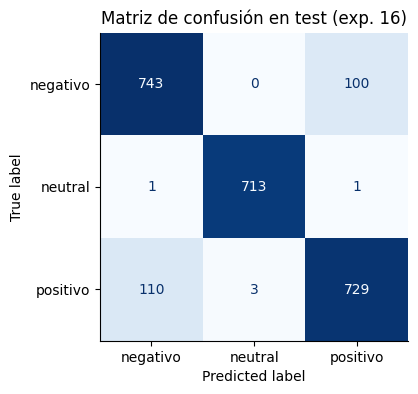

In [18]:
def crear_modelo_16():
    return Pipeline([
        ("normalizar", FunctionTransformer(normalizar_lote)),
        ("modelo", ModeloClausulas(combinador=hgb(4, 100, 0.05, 300, 1.0))),
    ])


ACC_FOLDS_E16 = folds["HGB muy simple (4 hojas, ≥100 por hoja)"]
print(f"CV experimento 16: {ACC_FOLDS_E16.mean():.4f} ± {ACC_FOLDS_E16.std():.4f} "
      f"| experimento 9: {ACC_FOLDS_E9.mean():.4f} ± {ACC_FOLDS_E9.std():.4f}")

inicio = time.time()
modelo_16 = crear_modelo_16().fit(X_train, y_train)
print(f"Entrenamiento en {(time.time() - inicio) / 60:.1f} min")

pred_test = modelo_16.predict(X_test)
print(f"\nTest -> accuracy: {accuracy_score(y_test, pred_test):.4f} | "
      f"F1 macro: {f1_score(y_test, pred_test, average='macro'):.4f}  (exp. 9: 0,9029)\n")
print(classification_report(y_test, pred_test, labels=CLASES, digits=3))
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Matriz de confusión en test (exp. 16)")
ax.grid(False)
plt.show()

### 6.2 Errores por grupo y robustez

In [19]:
np_test = (y_test != "neutral").to_numpy()
evasiva_test = X_test_norm.map(lambda t: es_evasiva(dividir_oraciones(t)[-1])).to_numpy()
acierto = pred_test == y_test.to_numpy()
display(pd.DataFrame({
    "reseñas": [(~np_test).sum(), (np_test & ~evasiva_test).sum(), (np_test & evasiva_test).sum()],
    "accuracy exp. 16": [acierto[~np_test].mean(), acierto[np_test & ~evasiva_test].mean(),
                         acierto[np_test & evasiva_test].mean()],
    "accuracy exp. 9": [0.999, 0.944, 0.460],
}, index=["neutral", "negativo/positivo sin final evasivo", "negativo/positivo con final evasivo"]).round(3))


def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    return pd.Series([" ".join(rng.permutation(dividir_oraciones(t))) if len(dividir_oraciones(t)) > 1 else t
                      for t in textos], index=textos.index)


pd.DataFrame({
    "exp. 16": [accuracy_score(y_test, pred_test),
                accuracy_score(y_test, modelo_16.predict(desordenar_oraciones(X_test_norm)))],
    "exp. 9": [0.9029, 0.7500],
}, index=["Original", "Oraciones desordenadas"]).round(4)

,reseñas,accuracy exp. 16,accuracy exp. 9
neutral,715,0.997,0.999
negativo/positivo sin final evasivo,1400,0.940,0.944
negativo/positivo con final evasivo,285,0.547,0.460


,exp. 16,exp. 9
Original,0.9104,0.9029
Oraciones desordenadas,0.7446,0.7500


La accuracy en test sube frente al experimento 9, pero hay que interpretarlo con cuidado: casi toda la ganancia está en el grupo con final evasivo, donde la etiqueta es aleatoria, así que esa diferencia es suerte. En las reseñas que sí se pueden predecir los dos modelos aciertan lo mismo (cerca de 94 %) y la robustez tampoco cambia. Por eso nos quedamos con lo que dice la validación cruzada, que es un empate con el experimento 9.

### 6.3 Importancia de las variables del combinador

Desordenamos una variable a la vez en los datos de validación del primer fold y medimos cuánto baja la accuracy. Entre más baja, más depende el modelo de esa variable.

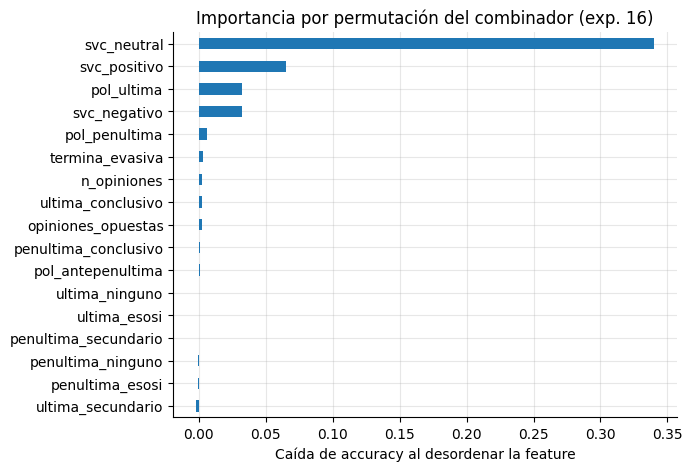

In [20]:
F_tr, F_va, y_tr, y_va = CACHE[0]
combinador = hgb(4, 100, 0.05, 300, 1.0).fit(F_tr, y_tr)
imp = permutation_importance(combinador, F_va, y_va, n_repeats=10, random_state=SEED, n_jobs=N_JOBS)
importancias = pd.Series(imp.importances_mean, index=NOMBRES_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(6.5, 5))
importancias.plot.barh(ax=ax)
ax.set_xlabel("Caída de accuracy al desordenar la feature")
ax.set_title("Importancia por permutación del combinador (exp. 16)")
plt.show()

Las variables más importantes son los puntajes del LinearSVC y la polaridad de la última opinión. Después vienen las de estructura (final evasivo, tipo de conector y opiniones opuestas), que son las que le permiten al combinador corregir al nivel 1 en los casos dudosos.

## 7. Envío y archivo del modelo

Entrenamos con las 12.000 reseñas, revisamos el formato y guardamos el envío y el modelo. El modelo guardado es el pipeline completo, así que recibe el texto sin procesar. Para cargar el `.joblib` en otra sesión primero hay que ejecutar las celdas de las secciones 1 y 4.

In [21]:
inicio = time.time()
modelo_final_16 = crear_modelo_16().fit(train["text"], train["label"])
print(f"Entrenamiento final en {(time.time() - inicio) / 60:.1f} min")

envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo_final_16.predict(eval_df["text"])})
assert list(envio.columns) == ["id", "answer"] and len(envio) == 3000
assert set(envio["id"]) == set(sample_submission["id"]) and set(envio["answer"]) <= set(CLASES)

Path("envios").mkdir(exist_ok=True)
Path("modelos").mkdir(exist_ok=True)
envio.to_csv("envios/submission_16.csv", index=False)
joblib.dump(modelo_final_16, "modelos/modelo_16.joblib")
assert (joblib.load("modelos/modelo_16.joblib").predict(eval_df["text"]) == envio["answer"].to_numpy()).all()
print("Guardados envios/submission_16.csv y modelos/modelo_16.joblib (se revisó que el modelo cargado da las mismas predicciones)")

if Path("envios/submission_09.csv").exists():
    e9 = pd.read_csv("envios/submission_09.csv")["answer"].to_numpy()
    print(f"Predicciones distintas a submission_09: {(e9 != envio['answer'].to_numpy()).sum()} de 3.000")
print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_dict())

Entrenamiento final en 4.3 min
Guardados envios/submission_16.csv y modelos/modelo_16.joblib (se revisó que el modelo cargado da las mismas predicciones)
{'negativo': 35.0, 'neutral': 27.6, 'positivo': 37.4}


## 8. Conclusiones

Sobreajuste
- La línea base y los modelos de texto de un nivel sí sobreajustan: en entrenamiento aciertan más que el techo de 0,937, lo que solo es posible memorizando etiquetas aleatorias.
- En el modelo del experimento 9 el sobreajuste está controlado gracias al cross-fitting, porque su accuracy de entrenamiento está en el techo.
- Según la curva de aprendizaje, más datos ayudarían poco. El límite está en el ruido de las etiquetas y en la representación.

Experimento 16
- Leer la reseña por cláusulas separa opiniones que están en la misma oración (0,6 puntos más en el modelo de un nivel).
- Los n-gramas de caracteres en la polaridad ayudan con tipeos y formas poco comunes de las palabras de opinión.
- El gradient boosting con árboles de 4 hojas captura interacciones como el SVM RBF, pero queda por debajo del techo en entrenamiento (1,7 puntos de diferencia, frente a 6,5 sin regularizar) y permite ver qué variables usa.
- La CV es 0,908 frente a 0,906 del experimento 9, una diferencia dentro del ruido, y la mejora en test viene del grupo de etiqueta aleatoria. No tenemos evidencia fuerte de que sea mejor en Kaggle, pero es un modelo que memoriza menos y es más fácil de explicar.

Envío
- Subimos `submission_16.csv` a Kaggle. Si supera 0,91555 en el leaderboard público, este pasa a ser el modelo de la entrega. Si no, se mantiene el experimento 9.
- Para el ranking privado conviene marcar el mejor envío público y este, porque se equivocan en reseñas distintas.

Limitaciones
- Cerca del 12,6 % de las etiquetas son aleatorias, así que ningún modelo va a pasar de 0,937.
- El modelo sigue dependiendo de que el veredicto esté al final de la reseña.
- Las listas de conectores y frases evasivas las construimos a mano y hay cierres evasivos que no están ("ahí lo dejamos", "es lo que hay por ahora").
- La segmentación en cláusulas es sencilla y a veces deja pedazos como "la uso casi todos los días, y".